In [3]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *
np.set_printoptions(suppress=True)

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [ ]:
def extract_gaze_windows_df(dEye, dHead, dGaze, gaze_onsets, gaze_timestamps, window_left, window_right, animal, date, normalize=True):
    """
    Extract gaze shift windows into a 3D array (n_gazes, 2 signals, window_samples).
    Automatically removes windows with all-zero signals.
    
    Parameters:
    - dEye, dHead, dGaze: 1D time series arrays
    - gaze_onsets: Indices where gaze shifts occur always [gazeL,gazeR]
    - gaze_timestamps: Timestamps corresponding to gaze onsets
    - window_left, window_right: Samples to include around onset
    - animal: Animal identifier
    - date: Date of recording
    - normalize: Scale each window to [-1, 1] (default: True)
    
    Returns:
    - output: 3D numpy array of raw windows (n_gazes, 2, window_size)
    - output_norm: 3D numpy array of normalized windows (n_gazes, 2, window_size)
    - metadata: pandas DataFrame with metadata for each gaze shift
    """
    dEye = np.asarray(dEye)
    dHead = np.asarray(dHead)
    dGaze = np.asarray(dGaze)
    gaze_onsets = np.asarray(gaze_onsets)
    gaze_timestamps = np.asarray(gaze_timestamps)
    
    if len(dEye) != len(dHead) or len(dEye) != len(dGaze):
        raise ValueError("dEye, dHead, and dGaze must have the same length")
    if len(gaze_onsets) != len(gaze_timestamps):
        raise ValueError("gaze_onsets and gaze_timestamps must have the same length")
    
    window_size = window_left + window_right + 1
    
    # Initialize lists to store valid windows and metadata
    valid_windows = []
    valid_windows_norm = []
    metadata_list = []
    
    for i, (onset, timestamp) in enumerate(zip(gaze_onsets, gaze_timestamps)):
        start = onset - window_left
        end = onset + window_right + 1
        
        # Skip out-of-bounds windows
        if start < 0 or end > len(dEye):
            continue
        
        # Skip NaN-containing windows (more efficient check)
        eye_win = dEye[start:end]
        head_win = dHead[start:end]
        gaze_value = dGaze[onset]  # Get dGaze value at onset point
        
        if np.isnan(eye_win).any() or np.isnan(head_win).any() or np.isnan(gaze_value):
            continue
        
        # Skip all-zero windows (more efficient check)
        if np.all(eye_win == 0) or np.all(head_win == 0):
            continue
        
        # Determine gaze direction and flip if necessary
        gaze_direction = 'left' if gaze_value >= 0 else 'right'
        if gaze_value < 0:
            eye_win = eye_win*-1
            head_win = head_win*-1
        
        # Normalize if required
        if normalize:
            def norm(x):
                x_min, x_max = x.min(), x.max()
                if x_max > x_min:
                    return 2 * ((x - x_min) / (x_max - x_min)) - 1
                return x
            norm_eye_win = norm(eye_win)
            norm_head_win = norm(head_win)
        else:
            norm_eye_win = eye_win
            norm_head_win = head_win
        
        # Store valid windows
        valid_windows.append([eye_win, head_win])
        valid_windows_norm.append([norm_eye_win, norm_head_win])
        
        # Add metadata
        metadata_list.append({
            'animal': animal,
            'date': date,
            'gaze_onset_index': onset,
            'gaze_timestamp': timestamp,
            'window_left': window_left,
            'window_right': window_right,
            'window_size': window_size,
            'has_nan': False,
            'is_zero': False,
            'gaze_direction': gaze_direction,
            'dGaze_value': gaze_value
        })
    
    # Convert to numpy arrays if we have valid data
    if valid_windows:
        output = np.stack([np.stack(w, axis=0) for w in valid_windows])
        output_norm = np.stack([np.stack(w, axis=0) for w in valid_windows_norm])
    else:
        output = np.empty((0, 2, window_size))
        output_norm = np.empty((0, 2, window_size))
    
    # Create metadata DataFrame
    metadata = pd.DataFrame(metadata_list)
    
    return output, output_norm, metadata

In [166]:

def npz_to_dataframe(npz_file):
    """
    Convert an NPZ file to a pandas DataFrame.
    
    Parameters:
    -----------
    npz_file : numpy.lib.npyio.NpzFile
        The loaded NPZ file object
        
    Returns:
    --------
    pd.DataFrame
        A DataFrame containing the data from the NPZ file
    """
    # Create a dictionary to hold arrays
    data_dict = {}
    
    # Extract all arrays from the NPZ file
    for key in npz_file.files:
        array_data = npz_file[key]
        
        # Handle 1D arrays (single column)
        if array_data.ndim == 1:
            data_dict[key] = array_data
        # Handle 2D arrays (multiple columns)
        elif array_data.ndim == 0:
            # If 2D array, create multiple columns with key prefix
            data_dict[key] = array_data.item()
        else:
           data_dict[key] = array_data.astype(object)
    
    # Create DataFrame from the dictionary
    #df = pd.DataFrame(data_dict)
    
    return data_dict

In [3]:
import numpy as np
import pandas as pd

def npz_to_single_row_dataframe(npz_file):
    """
    Convert an NPZ file to a single-row pandas DataFrame preserving arrays as objects.
    
    Parameters:
    -----------
    npz_file : numpy.lib.npyio.NpzFile
        The loaded NPZ file object
        
    Returns:
    --------
    pd.DataFrame
        A single-row DataFrame with scalar values and preserved arrays
    """
    # Initialize dictionary for the single row
    row_data = {}
    
    for key in npz_file.files:
        item = npz_file[key]
        
        # Handle scalar values (0D arrays or Python scalars)
        if isinstance(item, np.ndarray) and item.ndim == 0:
            row_data[key] = item.item()
        elif isinstance(item, (int, float, str, bool)) or item is None:
            row_data[key] = item
        # Handle arrays (store as objects)
        elif isinstance(item, np.ndarray):
            if item.ndim == 1:
                row_data[key] = item.astype(object)  # Store 1D array as object
            else:
                row_data[key] = item.astype(object)  # Store multi-dimensional array as object
        # Handle other types (lists, etc.)
        else:
            row_data[key] = item.astype(object)
    
    # Create single-row DataFrame
    df = pd.DataFrame([row_data])
    
    return df

In [7]:
def extract_head_windows_df(dHead, dGaze, gaze_onsets, gaze_timestamps, window_left, window_right, animal, date, normalize=True):
    """
    Extract head movement windows into a 2D array (n_gazes, window_samples).
    Automatically removes windows with all-zero signals.
    
    Parameters:
    - dHead: 1D time series array of head movements
    - dGaze: 1D time series array of gaze signals
    - gaze_onsets: Indices where gaze shifts occur always [gazeL,gazeR]
    - gaze_timestamps: Timestamps corresponding to gaze onsets
    - window_left, window_right: Samples to include around onset
    - animal: Animal identifier
    - date: Date of recording
    - normalize: Scale each window to [-1, 1] (default: True)
    
    Returns:
    - output: 2D numpy array of raw windows (n_gazes, window_size)
    - output_norm: 2D numpy array of normalized windows (n_gazes, window_size)
    - metadata: pandas DataFrame with metadata for each gaze shift
    """
    dHead = np.asarray(dHead)
    dGaze = np.asarray(dGaze)
    gaze_onsets = np.asarray(gaze_onsets)
    gaze_timestamps = np.asarray(gaze_timestamps)
    
    if len(dHead) != len(dGaze):
        raise ValueError("dHead and dGaze must have the same length")
    if len(gaze_onsets) != len(gaze_timestamps):
        raise ValueError("gaze_onsets and gaze_timestamps must have the same length")
    
    window_size = window_left + window_right + 1
    
    # Initialize lists to store valid windows and metadata
    valid_windows = []
    valid_windows_norm = []
    metadata_list = []
    
    for i, (onset, timestamp) in enumerate(zip(gaze_onsets, gaze_timestamps)):
        start = onset - window_left
        end = onset + window_right + 1
        
        # Skip out-of-bounds windows
        if start < 0 or end > len(dHead):
            continue
        
        # Extract window and check for NaNs
        head_win = dHead[start:end]
        gaze_value = dGaze[onset]  # Get dGaze value at onset point
        
        if np.isnan(head_win).any() or np.isnan(gaze_value):
            continue
        
        # Skip all-zero windows
        if np.all(head_win == 0):
            continue
        
        # Determine gaze direction and flip if necessary
        gaze_direction = 'left' if gaze_value >= 0 else 'right'
        if gaze_value < 0:
            head_win = head_win * -1
        
        # Normalize if required
        if normalize:
            def norm(x):
                x_min, x_max = x.min(), x.max()
                if x_max > x_min:
                    return 2 * ((x - x_min) / (x_max - x_min)) - 1
                return x
            norm_head_win = norm(head_win)
        else:
            norm_head_win = head_win
        
        # Store valid windows
        valid_windows.append(head_win)
        valid_windows_norm.append(norm_head_win)
        
        # Add metadata
        metadata_list.append({
            'animal': animal,
            'date': date,
            'gaze_onset_index': onset,
            'gaze_timestamp': timestamp,
            'window_left': window_left,
            'window_right': window_right,
            'window_size': window_size,
            'has_nan': False,
            'is_zero': False,
            'gaze_direction': gaze_direction,
            'dGaze_value': gaze_value
        })
    
    # Convert to numpy arrays if we have valid data
    if valid_windows:
        output = np.stack(valid_windows)
        output_norm = np.stack(valid_windows_norm)
    else:
        output = np.empty((0, window_size))
        output_norm = np.empty((0, window_size))
    
    # Create metadata DataFrame
    metadata = pd.DataFrame(metadata_list)
    
    return output, output_norm, metadata

In [179]:
npz_to_single_row_dataframe(F3LILT_050925_imu)

,animal,date,Usegood_reflec,spot_count,ellipticity,usegood_ellipcalb,ellipse,scale,cam_cent,pupil_count,...,eyeT,gazeL_event,gazeL_idx,gazeR_event,gazeR_idx,compL_event,compL_idx,compR_event,compR_idx,usegood_eyecalib
0,F3LILT,050925,"[True, True, True, True, True, True, True, Tru...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[0.4273056253988108, 0.8387024833010754, 0.834...","[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13...","[[3.682610401976506, 0.8658490039526463, 1.015...",34.368146,"[[12.60676530840216], [17.758242531405756]]","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ...",...,"[-0.6529539999974077, -0.6388165000025765, -0....","[0.02735949999623699, 0.22762900000088848, 0.5...","[41, 53, 75, 90, 104, 109, 130, 146, 170, 189,...","[-0.07252499999594875, 0.2752000000036787, 0.3...","[35, 56, 60, 77, 79, 84, 99, 103, 111, 118, 13...","[-0.08851199999480741, -0.04061449999426259, 0...","[34, 37, 46, 50, 64, 81, 86, 110, 122, 126, 12...","[-0.15685099999973318, -0.02469099999871105, 0...","[30, 38, 40, 42, 45, 57, 59, 62, 72, 76, 78, 8...","[True, True, True, True, True, True, True, Tru..."


In [6]:
F3LILT_050925_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\050925_F3LILT_imu_eyecam_dict.npz")
F3LILT_050725_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_imu_eyecam_dict.npz")
F3LILT_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\050825_F3LILT_imu_eyecam_dict.npz")
F3LILT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz")
F3LILT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_imu_eyecam_dict.npz")
F3LITT_050925_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\050925_F3LITT_imu_eyecam_dict.npz")
F3LITT_050725_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\050725_F3LITT_imu_eyecam_dict.npz")
F3LITT_050825_imu = np.load(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\050825_F3LITT_imu_eyecam_dict.npz")
F3LITT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_imu_eyecam_dict.npz")
F3LITT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_imu_eyecam_dict.npz")

In [38]:
npz_files = [
    F3LILT_050925_imu,
    F3LILT_050725_imu,
    F3LILT_050825_imu,
    F3LILT_051225_imu,
    F3LILT_051325_imu,
    F3LITT_050925_imu,
    F3LITT_050725_imu,
    F3LITT_050825_imu,
    F3LITT_051225_imu,
    F3LITT_051325_imu
]

In [39]:
F3LILT_F3LITT_all_imu= process_multiple_npz_files(npz_files)

In [40]:
F3LILT_F3LITT_all_imu.to_hdf(r'\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_imu_data_df.h5','F3LILT_F3LITT_all_imu_data_df.h5')

In [9]:


F3LILT_050925_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\cluster_F3LILT_050925_oa.h5")
F3LILT_050725_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\cluster_F3LILT_050725_oa.h5")
F3LILT_050825_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\cluster_F3LILT_050825_oa.h5")
F3LILT_051225_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
F3LILT_051325_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\cluster_F3LILT_051325_oa.h5")

F3LITT_050925_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\cluster_F3LITT_050925_oa.h5")
F3LITT_050725_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\cluster_F3LITT_050725_oa.h5")
F3LITT_050825_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\cluster_F3LITT_050825_oa.h5")
F3LITT_051225_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\cluster_F3LITT_051225_oa.h5")
F3LITT_051325_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\cluster_F3LITT_051325_oa.h5")


# List all DataFrames with their corresponding IDs
dfs = [
    (F3LILT_050925_df, "F3LILT_050925"),
    (F3LILT_050725_df, "F3LILT_050725"),
    (F3LILT_050825_df, "F3LILT_050825"),
    (F3LILT_051225_df, "F3LILT_051225"),
    (F3LILT_051325_df, "F3LILT_051325"),
    (F3LITT_050925_df, "F3LITT_050925"),
    (F3LITT_050725_df, "F3LITT_050725"),
    (F3LITT_050825_df, "F3LITT_050825"),
    (F3LITT_051225_df, "F3LITT_051225"),
    (F3LITT_051325_df, "F3LITT_051325"),
]

# Add a 'source' column to each DataFrame and concatenate
combined_df = pd.concat(
    [df.assign(source=source) for df, source in dfs],
    ignore_index=True  # Reset index to avoid duplicate indices
)

combined_df

combined_df.to_hdf(r'\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_data_df.h5','F3LILT_F3LITT_all_data_df.h5')

In [8]:
import numpy as np
import pandas as pd

def npz_to_single_row_dataframe(npz_file):
    """
    Base function: Convert an NPZ file to a single-row pandas DataFrame preserving arrays as objects.
    """
    row_data = {}
    
    for key in npz_file.files:
        item = npz_file[key]
        
        if isinstance(item, np.ndarray) and item.ndim == 0:
            row_data[key] = item.item()
        elif isinstance(item, (int, float, str, bool)) or item is None:
            row_data[key] = item
        elif isinstance(item, np.ndarray):
            row_data[key] = item.astype(object)
        else:
            row_data[key] = item
    
    return pd.DataFrame([row_data])

def process_multiple_npz_files(npz_files):
    """
    Process multiple NPZ files and vertically stack them into one DataFrame.
    
    Parameters:
    -----------
    npz_files : list
        List of either file paths (str) or loaded NpzFile objects
        
    Returns:
    --------
    pd.DataFrame
        Combined DataFrame with all data vertically stacked
    """
    dataframes = []
    
    for file in npz_files:
        # Handle both file paths and loaded NpzFile objects
        if isinstance(file, str):
            with np.load(file) as npz_data:
                df = npz_to_single_row_dataframe(npz_data)
        else:
            df = npz_to_single_row_dataframe(file)
        
        dataframes.append(df)
    
    # Vertically stack all DataFrames
    if dataframes:
        combined_df = pd.concat(dataframes, axis=0, ignore_index=True)
    else:
        combined_df = pd.DataFrame()
    
    return combined_df

In [10]:
window_left = 6 
window_right = 15

window_size = window_left + window_right+1


F3LILT_051325_imu_gaze_windows,norm_F3LILT_051325_imu_gaze_windows,F3LILT_051325_meta_df = extract_gaze_windows_df(dEye=F3LILT_051325_imu['dEye_dps'],dGaze=F3LILT_051325_imu['dGaze'],dHead=F3LILT_051325_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_051325_imu['gazeL_idx'],F3LILT_051325_imu['gazeR_idx']]),
                                                        animal=F3LILT_051325_imu['animal'],date=F3LILT_051325_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_051325_imu['gazeL_event'],F3LILT_051325_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LILT_051225_imu_gaze_windows,norm_F3LILT_051225_imu_gaze_windows,F3LILT_051225_meta_df = extract_gaze_windows_df(dEye=F3LILT_051225_imu['dEye_dps'],dGaze=F3LILT_051225_imu['dGaze'],dHead=F3LILT_051225_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_051225_imu['gazeL_idx'],F3LILT_051225_imu['gazeR_idx']]),
                                                        animal=F3LILT_051225_imu['animal'],date=F3LILT_051225_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_051225_imu['gazeL_event'],F3LILT_051225_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LILT_050925_imu_gaze_windows,norm_F3LILT_050925_imu_gaze_windows,F3LILT_050925_meta_df = extract_gaze_windows_df(dEye=F3LILT_050925_imu['dEye_dps'],dGaze=F3LILT_050925_imu['dGaze'],dHead=F3LILT_050925_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_050925_imu['gazeL_idx'],F3LILT_050925_imu['gazeR_idx']]),
                                                        animal=F3LILT_050925_imu['animal'],date=F3LILT_050925_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_050925_imu['gazeL_event'],F3LILT_050925_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LILT_050825_imu_gaze_windows,norm_F3LILT_050825_imu_gaze_windows,F3LILT_050825_meta_df = extract_gaze_windows_df(dEye=F3LILT_050825_imu['dEye_dps'],dGaze=F3LILT_050825_imu['dGaze'],dHead=F3LILT_050825_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_050825_imu['gazeL_idx'],F3LILT_050825_imu['gazeR_idx']]),
                                                        animal=F3LILT_050825_imu['animal'],date=F3LILT_050825_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_050825_imu['gazeL_event'],F3LILT_050825_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)

F3LILT_050725_imu_gaze_windows,norm_F3LILT_050725_imu_gaze_windows,F3LILT_050725_meta_df = extract_gaze_windows_df(dEye=F3LILT_050725_imu['dEye_dps'],dGaze=F3LILT_050725_imu['dGaze'],dHead=F3LILT_050725_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_050725_imu['gazeL_idx'],F3LILT_050725_imu['gazeR_idx']]),
                                                        animal=F3LILT_050725_imu['animal'],date=F3LILT_050725_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_050725_imu['gazeL_event'],F3LILT_050725_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)

In [ ]:
window_left = 15 
window_right = 15

window_size = window_left + window_right+1


F3LILT_051325_imu_gaze_windows,norm_F3LILT_051325_imu_gaze_windows,F3LILT_051325_meta_df = extract_gaze_windows_df(dEye=F3LILT_051325_imu['dEye_dps'],dGaze=F3LILT_051325_imu['dGaze'],dHead=F3LILT_051325_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_051325_imu['gazeL_idx'],F3LILT_051325_imu['gazeR_idx']]),
                                                        animal=F3LILT_051325_imu['animal'],date=F3LILT_051325_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_051325_imu['gazeL_event'],F3LILT_051325_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LILT_051225_imu_gaze_windows,norm_F3LILT_051225_imu_gaze_windows,F3LILT_051225_meta_df = extract_gaze_windows_df(dEye=F3LILT_051225_imu['dEye_dps'],dGaze=F3LILT_051225_imu['dGaze'],dHead=F3LILT_051225_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_051225_imu['gazeL_idx'],F3LILT_051225_imu['gazeR_idx']]),
                                                        animal=F3LILT_051225_imu['animal'],date=F3LILT_051225_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_051225_imu['gazeL_event'],F3LILT_051225_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LILT_050925_imu_gaze_windows,norm_F3LILT_050925_imu_gaze_windows,F3LILT_050925_meta_df = extract_gaze_windows_df(dEye=F3LILT_050925_imu['dEye_dps'],dGaze=F3LILT_050925_imu['dGaze'],dHead=F3LILT_050925_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_050925_imu['gazeL_idx'],F3LILT_050925_imu['gazeR_idx']]),
                                                        animal=F3LILT_050925_imu['animal'],date=F3LILT_050925_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_050925_imu['gazeL_event'],F3LILT_050925_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LILT_050825_imu_gaze_windows,norm_F3LILT_050825_imu_gaze_windows,F3LILT_050825_meta_df = extract_gaze_windows_df(dEye=F3LILT_050825_imu['dEye_dps'],dGaze=F3LILT_050825_imu['dGaze'],dHead=F3LILT_050825_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_050825_imu['gazeL_idx'],F3LILT_050825_imu['gazeR_idx']]),
                                                        animal=F3LILT_050825_imu['animal'],date=F3LILT_050825_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_050825_imu['gazeL_event'],F3LILT_050825_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)

F3LILT_050725_imu_gaze_windows,norm_F3LILT_050725_imu_gaze_windows,F3LILT_050725_meta_df = extract_gaze_windows_df(dEye=F3LILT_050725_imu['dEye_dps'],dGaze=F3LILT_050725_imu['dGaze'],dHead=F3LILT_050725_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LILT_050725_imu['gazeL_idx'],F3LILT_050725_imu['gazeR_idx']]),
                                                        animal=F3LILT_050725_imu['animal'],date=F3LILT_050725_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LILT_050725_imu['gazeL_event'],F3LILT_050725_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)

In [11]:
F3LITT_051325_imu_gaze_windows,norm_F3LITT_051325_imu_gaze_windows,F3LITT_051325_meta_df = extract_gaze_windows_df(dEye=F3LITT_051325_imu['dEye_dps'],dGaze=F3LITT_051325_imu['dGaze'],dHead=F3LITT_051325_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LITT_051325_imu['gazeL_idx'],F3LITT_051325_imu['gazeR_idx']]),
                                                        animal=F3LITT_051325_imu['animal'],date=F3LITT_051325_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LITT_051325_imu['gazeL_event'],F3LITT_051325_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LITT_051225_imu_gaze_windows,norm_F3LITT_051225_imu_gaze_windows,F3LITT_051225_meta_df = extract_gaze_windows_df(dEye=F3LITT_051225_imu['dEye_dps'],dGaze=F3LITT_051225_imu['dGaze'],dHead=F3LITT_051225_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LITT_051225_imu['gazeL_idx'],F3LITT_051225_imu['gazeR_idx']]),
                                                        animal=F3LITT_051225_imu['animal'],date=F3LITT_051225_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LITT_051225_imu['gazeL_event'],F3LITT_051225_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LITT_050925_imu_gaze_windows,norm_F3LITT_050925_imu_gaze_windows,F3LITT_050925_meta_df = extract_gaze_windows_df(dEye=F3LITT_050925_imu['dEye_dps'],dGaze=F3LITT_050925_imu['dGaze'],dHead=F3LITT_050925_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LITT_050925_imu['gazeL_idx'],F3LITT_050925_imu['gazeR_idx']]),
                                                        animal=F3LITT_050925_imu['animal'],date=F3LITT_050925_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LITT_050925_imu['gazeL_event'],F3LITT_050925_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)


F3LITT_050825_imu_gaze_windows,norm_F3LITT_050825_imu_gaze_windows,F3LITT_050825_meta_df = extract_gaze_windows_df(dEye=F3LITT_050825_imu['dEye_dps'],dGaze=F3LITT_050825_imu['dGaze'],dHead=F3LITT_050825_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LITT_050825_imu['gazeL_idx'],F3LITT_050825_imu['gazeR_idx']]),
                                                        animal=F3LITT_050825_imu['animal'],date=F3LITT_050825_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LITT_050825_imu['gazeL_event'],F3LITT_050825_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)

F3LITT_050725_imu_gaze_windows,norm_F3LITT_050725_imu_gaze_windows,F3LITT_050725_meta_df = extract_gaze_windows_df(dEye=F3LITT_050725_imu['dEye_dps'],dGaze=F3LITT_050725_imu['dGaze'],dHead=F3LITT_050725_imu['dHead'],
                                                        gaze_onsets=np.hstack([F3LITT_050725_imu['gazeL_idx'],F3LITT_050725_imu['gazeR_idx']]),
                                                        animal=F3LITT_050725_imu['animal'],date=F3LITT_050725_imu['date'],
                                                        gaze_timestamps=np.hstack([F3LITT_050725_imu['gazeL_event'],F3LITT_050725_imu['gazeR_event']]),
                            window_left=window_left,window_right=window_right,normalize=True)

In [12]:
norm_F3LILT_F3LITT_all_gaze_windows = np.concatenate([norm_F3LILT_051325_imu_gaze_windows,norm_F3LILT_051225_imu_gaze_windows,
                                               norm_F3LILT_050925_imu_gaze_windows,norm_F3LILT_050825_imu_gaze_windows,norm_F3LILT_050725_imu_gaze_windows,
                                               norm_F3LITT_051325_imu_gaze_windows,norm_F3LITT_051225_imu_gaze_windows,
                                               norm_F3LITT_050925_imu_gaze_windows,norm_F3LITT_050825_imu_gaze_windows,norm_F3LITT_050725_imu_gaze_windows])

F3LILT_F3LITT_all_gaze_windows = np.concatenate([F3LILT_051325_imu_gaze_windows,F3LILT_051225_imu_gaze_windows,
                                          F3LILT_050925_imu_gaze_windows,F3LILT_050825_imu_gaze_windows,F3LILT_050725_imu_gaze_windows,
                                          F3LITT_051325_imu_gaze_windows,F3LITT_051225_imu_gaze_windows,
                                          F3LITT_050925_imu_gaze_windows,F3LITT_050825_imu_gaze_windows,F3LITT_050725_imu_gaze_windows])

F3LILT_F3LITT_all_meta = pd.concat([F3LILT_051325_meta_df,F3LILT_051225_meta_df,
                                          F3LILT_050925_meta_df,F3LILT_050825_meta_df,F3LILT_050725_meta_df,
                                          F3LITT_051325_meta_df,F3LITT_051225_meta_df,
                                          F3LITT_050925_meta_df,F3LITT_050825_meta_df,F3LITT_050725_meta_df])


In [13]:
n_gazes = F3LILT_F3LITT_all_gaze_windows.shape[0]
flattened_data = F3LILT_F3LITT_all_gaze_windows.reshape(n_gazes, -1)
norm_flattened_data = norm_F3LILT_F3LITT_all_gaze_windows.reshape(n_gazes, -1)



In [1243]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(norm_flattened_data)

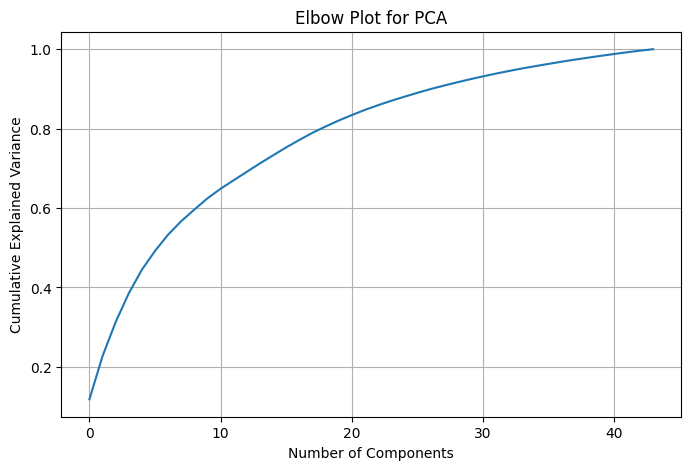

In [14]:
pca = PCA().fit(norm_flattened_data)

# Create elbow plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Plot for PCA')
plt.grid()
plt.show()

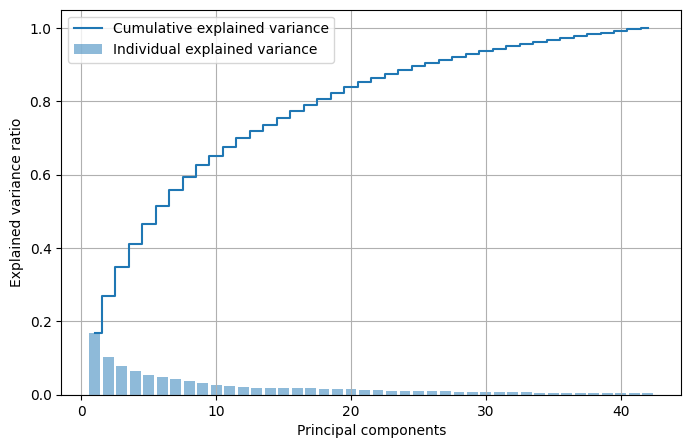

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 
        alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), 
         where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.grid()
plt.show()

In [1290]:
from sklearn.decomposition import PCA

pca = PCA(n_components=12) # Keep 95% of variance (adjust as needed)
pca_data = pca.fit_transform(norm_flattened_data)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Reduced dimensions: {pca_data.shape}")  # 

Explained variance ratio: [0.12375141 0.10832923 0.08345805 0.07181818 0.05831813 0.04626631
 0.04061945 0.03396593 0.02879004 0.02769288 0.02407921 0.0208938 ]
Reduced dimensions: (13735, 12)


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4) # Keep 95% of variance (adjust as needed)
pca_data = pca.fit_transform(norm_flattened_data)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Reduced dimensions: {pca_data.shape}")  

Explained variance ratio: [0.11839744 0.1088204  0.08571793 0.07230941]
Reduced dimensions: (19815, 4)


In [1275]:
from sklearn.decomposition import PCA

pca = PCA(n_components=.95) # Keep 95% of variance (adjust as needed)
pca_data = pca.fit_transform(norm_flattened_data)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Reduced dimensions: {pca_data.shape}")  # 

Explained variance ratio: [0.1230683  0.11514568 0.09609053 0.06956796 0.06151799 0.04811948
 0.04316636 0.03306622 0.03198937 0.02844598 0.02620102 0.02388214
 0.02331333 0.02272633 0.02071094 0.01959732 0.01823988 0.01722099
 0.01499217 0.01409313 0.01353795 0.01254612 0.01168506 0.01092075
 0.01021626 0.00962545 0.00886245 0.00837282 0.00769926 0.00751965]
Reduced dimensions: (13838, 30)


In [16]:
from sklearn.cluster import KMeans

n_clusters = 4#4 # Choose based on your data (e.g., elbow method)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(pca_data)

print("Cluster labels:", clusters)  # Array of cluster indices (0, 1, 2, ...)

Cluster labels: [0 0 1 ... 3 3 3]


In [24]:
clusters.shape

(19815,)

In [17]:
F3LILT_F3LITT_all_meta['cluster'] = clusters

In [ ]:
F3LILT_F3LITT_all_meta.to_hdf(r'\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_meta.h5','F3LILT_F3LITT_all_gaze.h5',mode='w')

In [31]:
F3LILT_F3LITT_all_meta = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_meta.h5")

In [18]:
F3LILT_F3LITT_all_meta

,animal,date,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,gaze_direction,dGaze_value,cluster
0,F3LILT,051325,78,0.629773,6,15,22,False,False,left,251.500473,0
1,F3LILT,051325,81,0.679610,6,15,22,False,False,left,354.582225,0
2,F3LILT,051325,84,0.729920,6,15,22,False,False,left,390.833279,1
3,F3LILT,051325,95,0.914112,6,15,22,False,False,left,1020.701578,0
4,F3LILT,051325,109,1.148077,6,15,22,False,False,left,625.149695,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1352,F3LITT,050725,76267,1271.888230,6,15,22,False,False,right,-323.817400,0
1353,F3LITT,050725,76321,1272.788281,6,15,22,False,False,right,-292.850515,3
1354,F3LITT,050725,76324,1272.836736,6,15,22,False,False,right,-254.157783,3
1355,F3LITT,050725,76349,1273.256518,6,15,22,False,False,right,-256.430384,3


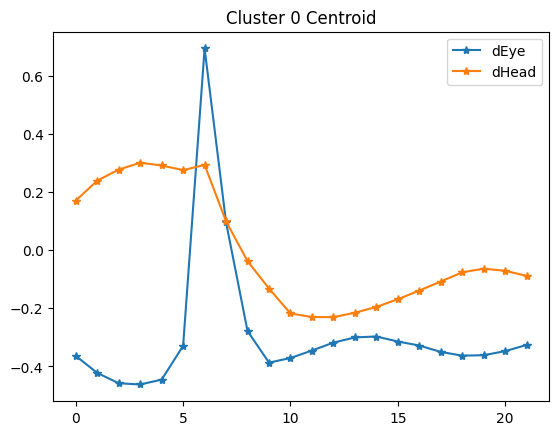

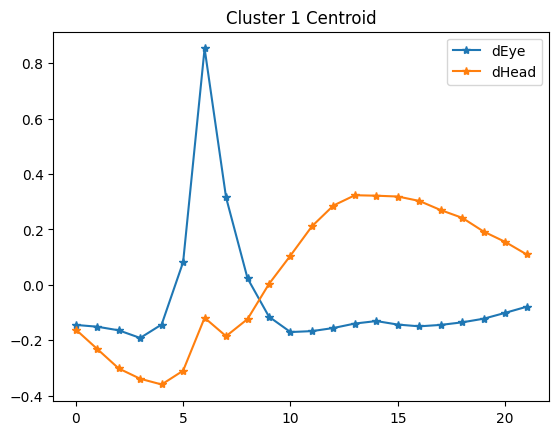

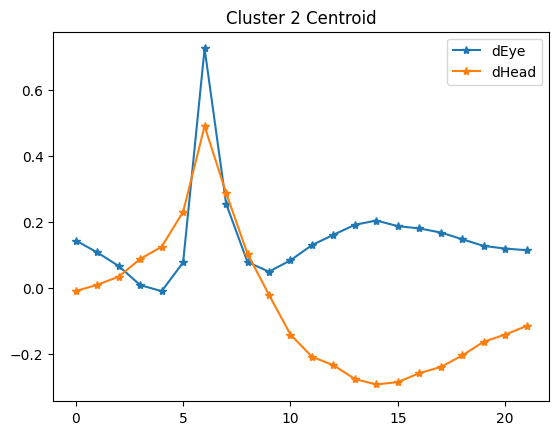

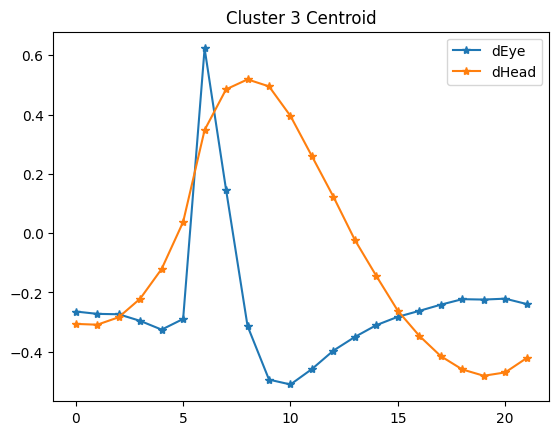

In [19]:
# Get centroids in PCA space
centroids = kmeans.cluster_centers_

# Inverse transform to original feature space
centroids_original = pca.inverse_transform(centroids)
#centroids_original = scaler.inverse_transform(centroids_original)
centroids_original = centroids_original.reshape(n_clusters, 2, -1)  # (n_clusters, 2, window_size)

# Plot centroid windows
for cluster in range(n_clusters):
    plt.figure()
    plt.plot(centroids_original[cluster, 0, :], '-*',label="dEye")
    plt.plot(centroids_original[cluster, 1, :], '-*',label="dHead")
    plt.title(f"Cluster {cluster} Centroid")
    plt.legend()
    #plt.ylim(-.5,.5)
    plt.show()


In [ ]:
cluster_groups = {}
for cluster_id in np.unique(clusters):
    cluster_groups[cluster_id] = flattened_data[clusters == cluster_id]

# Example: Access all samples in Cluster 0
print("Cluster 0 shape:", cluster_groups[0].shape)  # (n_samples_in_cluster, 2 * window_size)
norm_cluster_groups = {}
for cluster_id in np.unique(clusters):
    norm_cluster_groups[cluster_id] = norm_flattened_data[clusters == cluster_id]

# Example: Access all samples in Cluster 0
print("Cluster 0 shape:", cluster_groups[0].shape)  # (n_samples_in_cluster, 2 * window_size)

Cluster 0 shape: (4892, 44)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import matplotlib.ticker as ticker

def plot_cluster_traces(cluster_groups, window_size, window_left, centroids, 
                       save_dir='./', filename='cluster_traces.pdf',
                       fig_width=12, fig_height_per_row=4,
                       plot_individual_traces=False,
                       max_individual_traces=100,
                       plot_std_dev=True,
                       use_normalized_axis=False,
                       raw_axis_limits=(-500, 500)):
    """
    Plots mean and individual traces for each cluster group in a 2-per-row layout and saves as PDF.
    
    Parameters:
    - cluster_groups: Dictionary {cluster_id: flattened_data_array}
    - window_size: Length of the original window
    - window_left: Index of window center
    - centroids: Array of cluster centroids (n_clusters, 2, window_size)
    - save_dir: Directory to save PDF (created if doesn't exist)
    - filename: Name of output PDF file
    - fig_width: Total figure width in inches
    - fig_height_per_row: Height per row of subplots in inches
    - plot_individual_traces: Whether to plot individual traces (default: False)
    - max_individual_traces: Maximum number of individual traces to plot (default: 100)
    - plot_std_dev: Whether to plot standard deviation bands (default: True)
    - use_normalized_axis: Use normalized y-axis (-1 to 1) if True (default: False)
    - raw_axis_limits: Tuple of (min, max) for raw axis limits (default: (-500, 500))
    """
    def column_standard_errors(data):
        """Calculate standard deviation for each column in a 2D array."""
        arr = np.array(data)
        return np.std(arr, axis=0, ddof=1)  # sample standard deviation

    def frames_to_seconds(x, pos, fps=60):
        return f"{x / fps:.2f}"

    n_clusters = len(cluster_groups)
    n_rows = int(np.ceil(n_clusters / 2))
    fig_height = fig_height_per_row * n_rows
    
    # Create figure with subplots
    fig, axs = plt.subplots(n_rows, 2, figsize=(fig_width, fig_height))
    axs = axs.flatten() if isinstance(axs, np.ndarray) else [axs]
    
    # Set y-axis limits based on parameters
    y_lim = (-1, 1) if use_normalized_axis else raw_axis_limits
    
    for idx, cluster_id in enumerate(sorted(cluster_groups.keys())):
        ax = axs[idx]
        cluster_data = cluster_groups[cluster_id]
        n_traces = cluster_data.shape[0]
        
        # Reshape data
        reshaped_data = cluster_data.reshape(-1, 2, window_size)
        dEye_traces = reshaped_data[:, 0, :]
        dHead_traces = reshaped_data[:, 1, :]
        
        # Create time axis (centered at window_left)
        time_axis = np.arange(0, window_size) - window_left
        
        # Plot individual traces if requested
        if plot_individual_traces:
            # Determine how many traces to actually plot (up to max_individual_traces)
            n_to_plot = min(dEye_traces.shape[0], max_individual_traces)
            
            # Randomly select traces if there are more than max_individual_traces
            if dEye_traces.shape[0] > max_individual_traces:
                rng = np.random.default_rng(42)  # Seed for reproducibility
                indices = rng.choice(dEye_traces.shape[0], size=n_to_plot, replace=False)
                dEye_to_plot = dEye_traces[indices]
                dHead_to_plot = dHead_traces[indices]
            else:
                dEye_to_plot = dEye_traces
                dHead_to_plot = dHead_traces
            
            # Plot the subset of traces
            for i in range(n_to_plot):
                ax.plot(time_axis, dEye_to_plot[i], color='lightcoral', alpha=0.5, linewidth=0.5)
                ax.plot(time_axis, dHead_to_plot[i], color='lightblue', alpha=0.5, linewidth=0.5)
        
        # Plot mean traces
        ax.plot(time_axis, np.nanmean(dEye_traces, axis=0), 
                color='red', label='Mean dEye', linewidth=2)
        ax.plot(time_axis, np.nanmean(dHead_traces, axis=0), 
                color='blue', label='Mean dHead', linewidth=2)
        ax.plot(time_axis, np.nanmean(dEye_traces, axis=0)+np.nanmean(dHead_traces, axis=0), 
                color='green', label='Mean dGaze', linewidth=2)
        
        # Plot standard deviation if requested
        if plot_std_dev:
            dEye_std = column_standard_errors(dEye_traces)
            dHead_std = column_standard_errors(dHead_traces)
            dGaze_std = column_standard_errors(dEye_traces+dHead_traces)
            
            ax.fill_between(time_axis, 
                          np.nanmean(dEye_traces, axis=0) - dEye_std,
                          np.nanmean(dEye_traces, axis=0) + dEye_std,
                          color='red', alpha=0.3)
            
            ax.fill_between(time_axis,
                          np.nanmean(dHead_traces, axis=0) - dHead_std,
                          np.nanmean(dHead_traces, axis=0) + dHead_std,
                          color='blue', alpha=0.3)
        
        # Format subplot
        ax.set_title(f'Cluster {cluster_id} (n={n_traces})')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('dps' if not use_normalized_axis else 'Normalized units')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(y_lim)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
    
    # Hide unused subplots
    for j in range(n_clusters, len(axs)):
        axs[j].axis('off')
    
    plt.tight_layout()
    
    # Save to PDF
    save_path = Path(save_dir) / filename
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.close()
    
    print(f"Saved plot to: {save_path}")

In [26]:
raw_std_fig = plot_cluster_traces(cluster_groups, window_size=window_size,window_left=window_left, 
                                  centroids=centroids_original,plot_individual_traces=False,plot_std_dev=True,save_dir=r'\\goeppert\Vol2\mike\figures\dac_2025',filename='F3LILT_F3LITT_gaze_clusters_raw_data_std_dev')

Saved plot to: \\goeppert\Vol2\mike\figures\dac_2025\F3LILT_F3LITT_gaze_clusters_raw_data_std_dev


In [27]:
raw_traces_fig = plot_cluster_traces(cluster_groups, window_size=window_size,window_left=window_left, centroids=centroids_original,
                                     plot_individual_traces=True,plot_std_dev=False,save_dir=r'\\goeppert\Vol2\mike\figures\dac_2025',filename='F3LILT_F3LITT_gaze_clusters_raw_data_traces')

Saved plot to: \\goeppert\Vol2\mike\figures\dac_2025\F3LILT_F3LITT_gaze_clusters_raw_data_traces


In [28]:
norm_std_fig = plot_cluster_traces(norm_cluster_groups, window_size=window_size,window_left=window_left, 
                                  centroids=centroids_original,plot_individual_traces=False,plot_std_dev=True,use_normalized_axis=True,save_dir=r'\\goeppert\Vol2\mike\figures\dac_2025',filename='F3LILT_F3LITT_gaze_clusters_norm_data_std_dev')

Saved plot to: \\goeppert\Vol2\mike\figures\dac_2025\F3LILT_F3LITT_gaze_clusters_norm_data_std_dev


In [29]:
norm_traces_fig = plot_cluster_traces(norm_cluster_groups, window_size=window_size,window_left=window_left, 
                                  centroids=centroids_original,plot_individual_traces=True,plot_std_dev=False,use_normalized_axis=True,save_dir=r'\\goeppert\Vol2\mike\figures\dac_2025',filename='F3LILT_F3LITT_gaze_clusters_norm_data_traces')

Saved plot to: \\goeppert\Vol2\mike\figures\dac_2025\F3LILT_F3LITT_gaze_clusters_norm_data_traces


In [43]:
F3LILT_F3LITT_all_meta

,animal,date,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,gaze_direction,dGaze_value,cluster
0,F3LILT,051325,78,0.629773,6,15,22,False,False,left,251.500473,0
1,F3LILT,051325,81,0.679610,6,15,22,False,False,left,354.582225,0
2,F3LILT,051325,84,0.729920,6,15,22,False,False,left,390.833279,1
3,F3LILT,051325,95,0.914112,6,15,22,False,False,left,1020.701578,0
4,F3LILT,051325,109,1.148077,6,15,22,False,False,left,625.149695,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1352,F3LITT,050725,76267,1271.888230,6,15,22,False,False,right,-323.817400,0
1353,F3LITT,050725,76321,1272.788281,6,15,22,False,False,right,-292.850515,3
1354,F3LITT,050725,76324,1272.836736,6,15,22,False,False,right,-254.157783,3
1355,F3LITT,050725,76349,1273.256518,6,15,22,False,False,right,-256.430384,3


In [42]:
F3LILT_all_meta

NameError: name 'F3LILT_all_meta' is not defined

In [31]:
F3LILT_F3LITT_all_meta.date = F3LILT_F3LITT_all_meta.date.astype('string')

In [32]:
F3LILT_F3LITT_all_meta.date = F3LILT_F3LITT_all_meta.date.astype('object')

In [41]:
F3LILT_F3LITT_all_meta.groupby('date').count()

,animal,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,gaze_direction,dGaze_value,cluster
date,,,,,,,,,,,
050725,5372,5372,5372,5372,5372,5372,5372,5372,5372,5372,5372
050825,3736,3736,3736,3736,3736,3736,3736,3736,3736,3736,3736
050925,4431,4431,4431,4431,4431,4431,4431,4431,4431,4431,4431
051225,2910,2910,2910,2910,2910,2910,2910,2910,2910,2910,2910
051325,3366,3366,3366,3366,3366,3366,3366,3366,3366,3366,3366


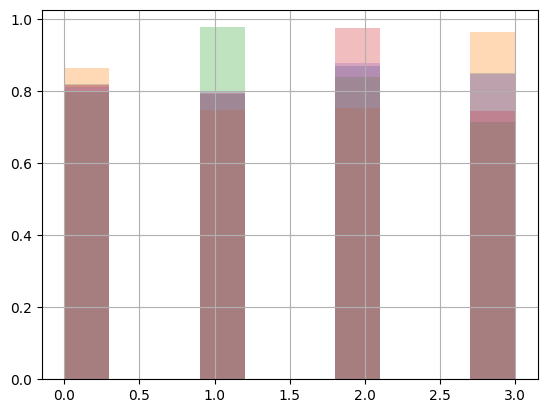

In [34]:
for date,df in F3LILT_F3LITT_all_meta.groupby(['date']):
    df['cluster'].hist(alpha =.3,density=True)


In [36]:
F3LILT_F3LITT_all_meta.to_hdf(r'\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_gaze.h5','F3LILT_F3LITT_all_gaze.h5',mode='w')

In [198]:
F3LILT_F3LITT_all_meta

,animal,date,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,gaze_direction,dGaze_value,cluster
0,F3LILT,051325,78,0.629773,6,15,22,False,False,left,251.500473,0
1,F3LILT,051325,81,0.679610,6,15,22,False,False,left,354.582225,0
2,F3LILT,051325,84,0.729920,6,15,22,False,False,left,390.833279,1
3,F3LILT,051325,95,0.914112,6,15,22,False,False,left,1020.701578,0
4,F3LILT,051325,109,1.148077,6,15,22,False,False,left,625.149695,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1352,F3LITT,050725,76267,1271.888230,6,15,22,False,False,right,-323.817400,0
1353,F3LITT,050725,76321,1272.788281,6,15,22,False,False,right,-292.850515,3
1354,F3LITT,050725,76324,1272.836736,6,15,22,False,False,right,-254.157783,3
1355,F3LITT,050725,76349,1273.256518,6,15,22,False,False,right,-256.430384,3


In [196]:


F3LILT_050925_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050925\F3LILT\oa_cam\cluster_F3LILT_050925_oa.h5")
F3LILT_050725_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\cluster_F3LILT_050725_oa.h5")
F3LILT_050825_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050825\F3LILT\oa_cam1\cluster_F3LILT_050825_oa.h5")
F3LILT_051225_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
F3LILT_051325_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\cluster_F3LILT_051325_oa.h5")

F3LITT_050925_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050925\F3LITT\oa_cam\cluster_F3LITT_050925_oa.h5")
F3LITT_050725_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\cluster_F3LITT_050725_oa.h5")
F3LITT_050825_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\050825\F3LITT\oa_cam\cluster_F3LITT_050825_oa.h5")
F3LITT_051225_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\cluster_F3LITT_051225_oa.h5")
F3LITT_051325_df = pd.read_hdf(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\cluster_F3LITT_051325_oa.h5")


# List all DataFrames with their corresponding IDs
dfs = [
    (F3LILT_050925_df, "F3LILT_050925"),
    (F3LILT_050725_df, "F3LILT_050725"),
    (F3LILT_050825_df, "F3LILT_050825"),
    (F3LILT_051225_df, "F3LILT_051225"),
    (F3LILT_051325_df, "F3LILT_051325"),
    (F3LITT_050925_df, "F3LITT_050925"),
    (F3LITT_050725_df, "F3LITT_050725"),
    (F3LITT_050825_df, "F3LITT_050825"),
    (F3LITT_051225_df, "F3LITT_051225"),
    (F3LITT_051325_df, "F3LITT_051325"),
]

# Add a 'source' column to each DataFrame and concatenate
combined_df = pd.concat(
    [df.assign(source=source) for df, source in dfs],
    ignore_index=True  # Reset index to avoid duplicate indices
)

combined_df

combined_df.to_hdf(r'\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_data_df.h5','F3LILT_F3LITT_all_data_df.h5')

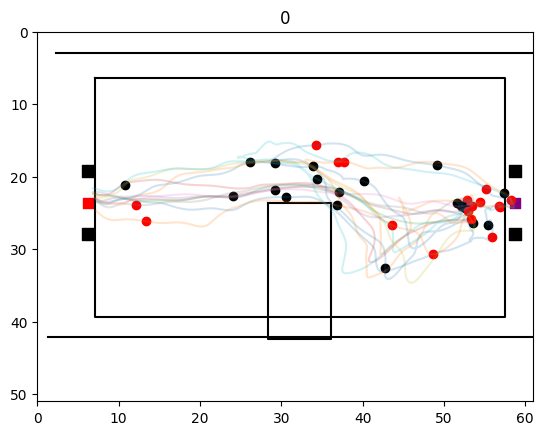

In [103]:
cluster_df = F3LILT_051225_df[(F3LILT_051225_df['obstacle_cluster']==2)&(F3LILT_051225_df['odd']=='right')]
imu = F3LILT_051225_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051225') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 0
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].gaze_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

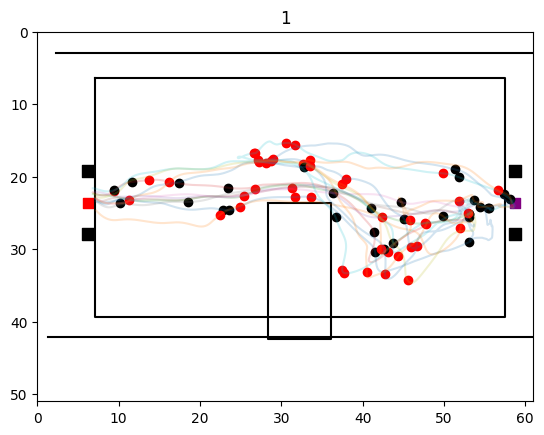

In [101]:
cluster_df = F3LILT_051225_df[(F3LILT_051225_df['obstacle_cluster']==2)&(F3LILT_051225_df['odd']=='right')]
imu = F3LILT_051225_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051225') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 1
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].gaze_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

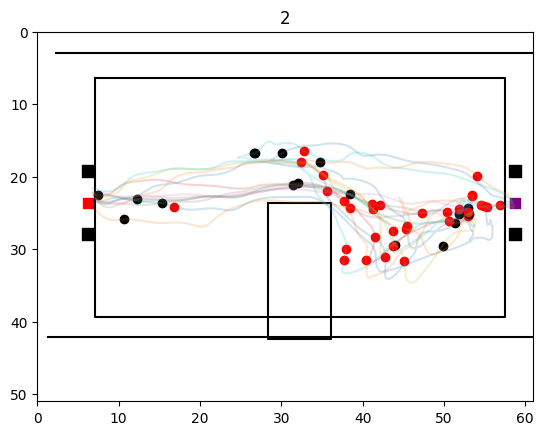

In [104]:
cluster_df = F3LILT_051225_df[(F3LILT_051225_df['obstacle_cluster']==2)&(F3LILT_051225_df['odd']=='right')]
imu = F3LILT_051225_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051225') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 2
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].gaze_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

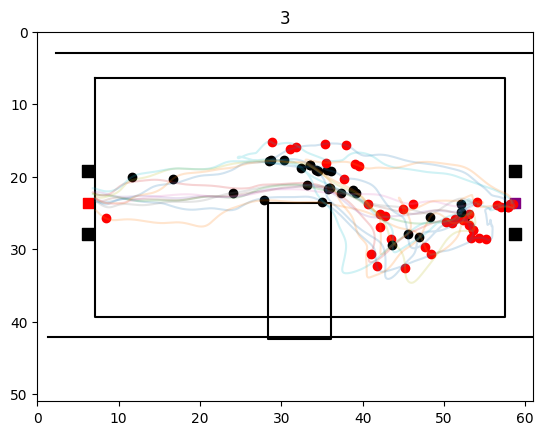

In [102]:
cluster_df = F3LILT_051225_df[(F3LILT_051225_df['obstacle_cluster']==2)&(F3LILT_051225_df['odd']=='right')]
imu = F3LILT_051225_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051225') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 3
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].gaze_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

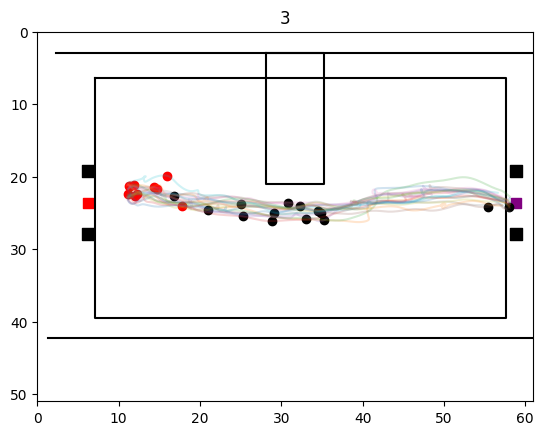

In [92]:
cluster_df = F3LITT_051325_df[(F3LITT_051325_df['obstacle_cluster']==0)&(F3LITT_051325_df['odd']=='left')]
imu = F3LITT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051325') &(F3LILT_F3LITT_all_meta.animal == 'F3LITT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 3
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].gaze_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

In [54]:
obstacle_cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==0) & (F3LILT_051325_df['odd']=='right')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325')]
gaze_timestmps = gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

NameError: name 'F3LILT_all_meta' is not defined

In [55]:
obstacle_cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==0) & (F3LILT_051325_df['odd']=='left')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325')]
gaze_timestmps = gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

NameError: name 'F3LILT_all_meta' is not defined

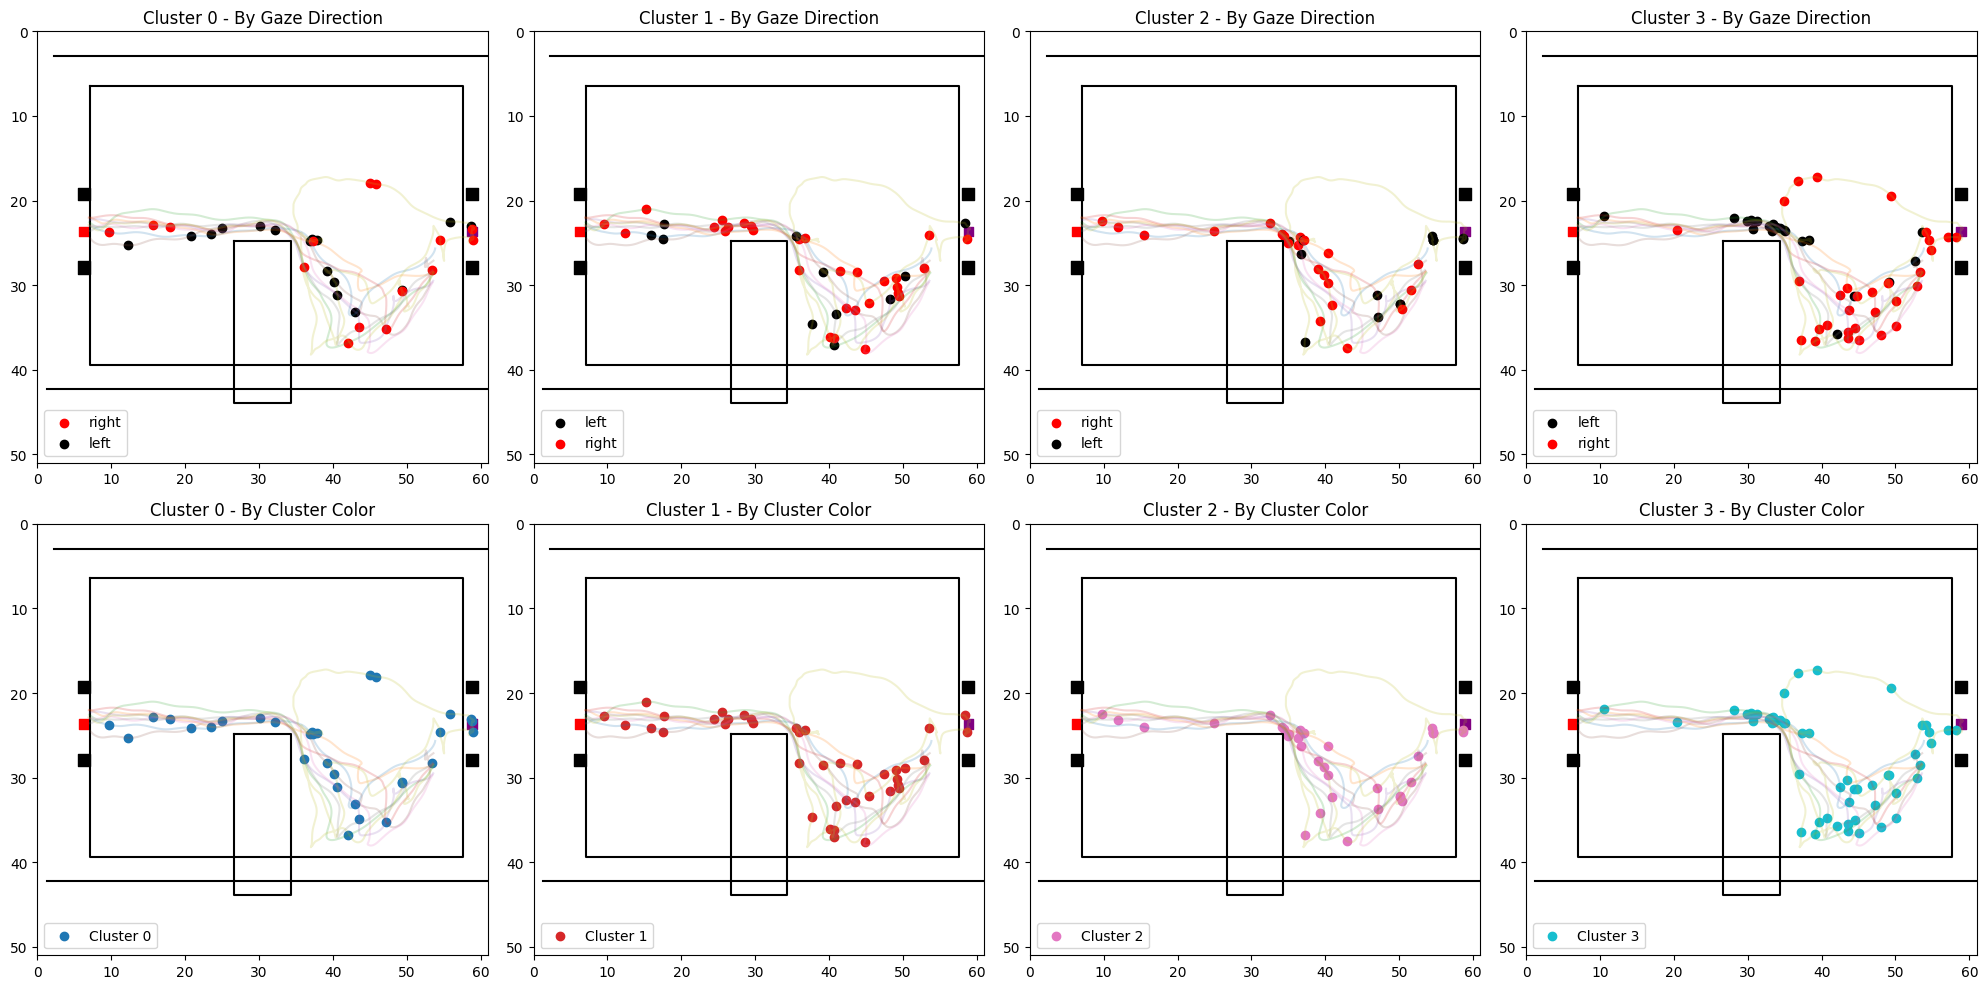

In [53]:
obstacle_cluster_df = F3LILT_050825_df[(F3LILT_050825_df['obstacle_cluster']==2)&(F3LILT_050825_df['odd']=='right')]
imu = F3LILT_050825_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '050825') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

In [ ]:
F3

In [57]:
F3LILT_F3LITT_df

NameError: name 'F3LILT_F3LITT_df' is not defined

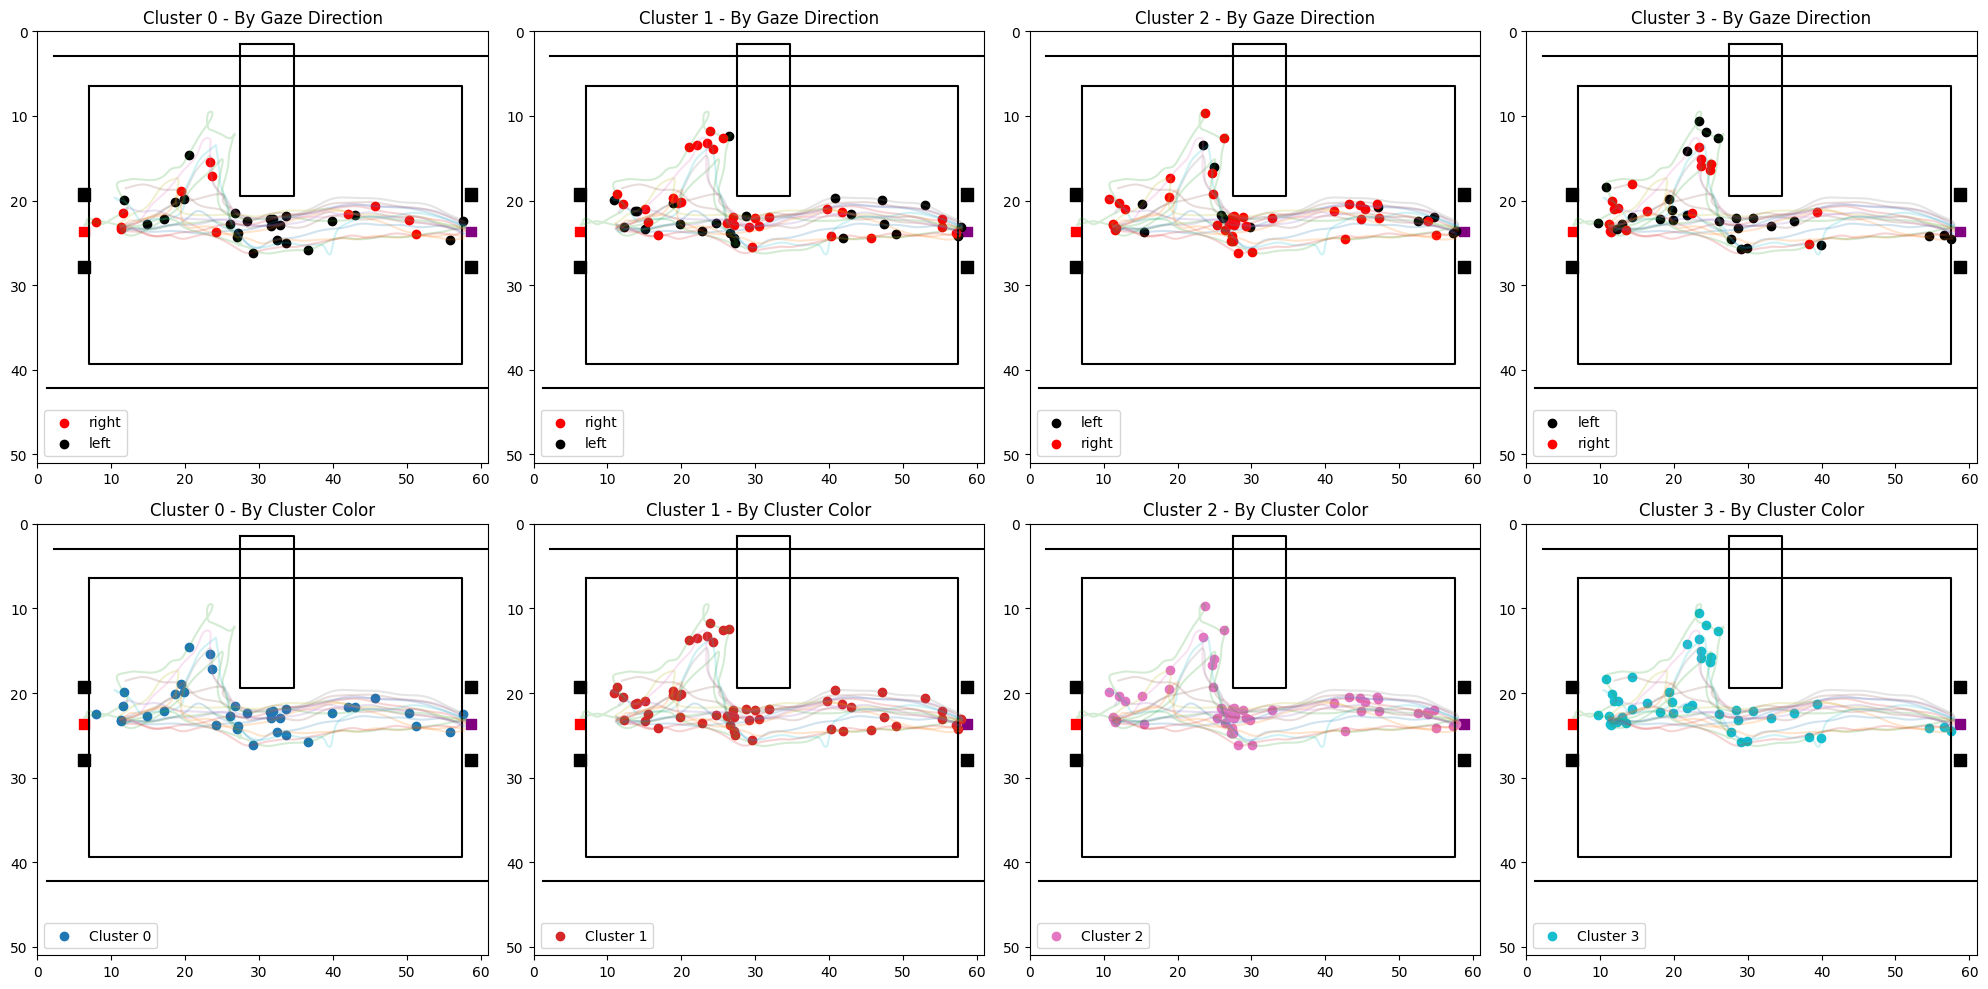

In [68]:
obstacle_cluster_df = F3LILT_051225_df[(F3LILT_051225_df['obstacle_cluster']==0)&(F3LILT_051225_df['odd']=='left')]
imu = F3LILT_051225_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051225') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

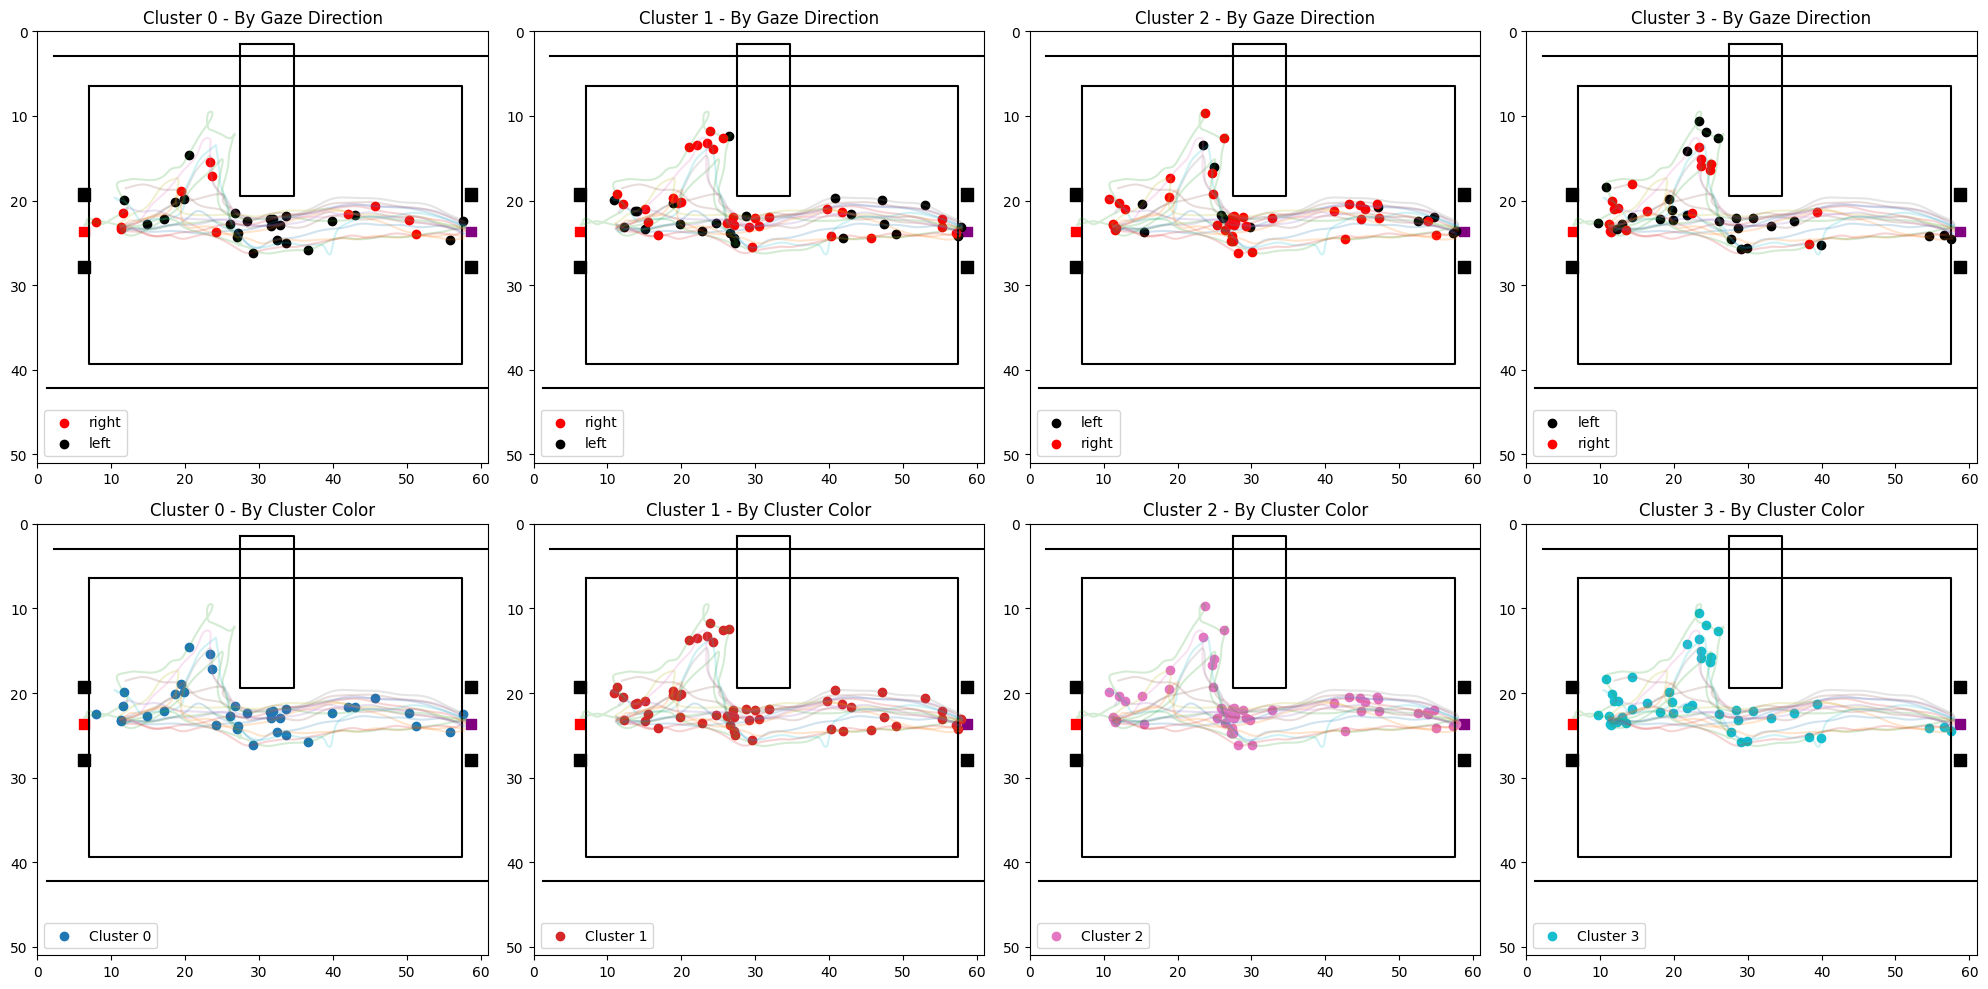

In [64]:
obstacle_cluster_df = F3LILT_051225_df[(F3LILT_051225_df['obstacle_cluster']==0)&(F3LILT_051225_df['odd']=='left')]
imu = F3LILT_051225_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051225') &(F3LILT_F3LITT_all_meta.animal == 'F3LILT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

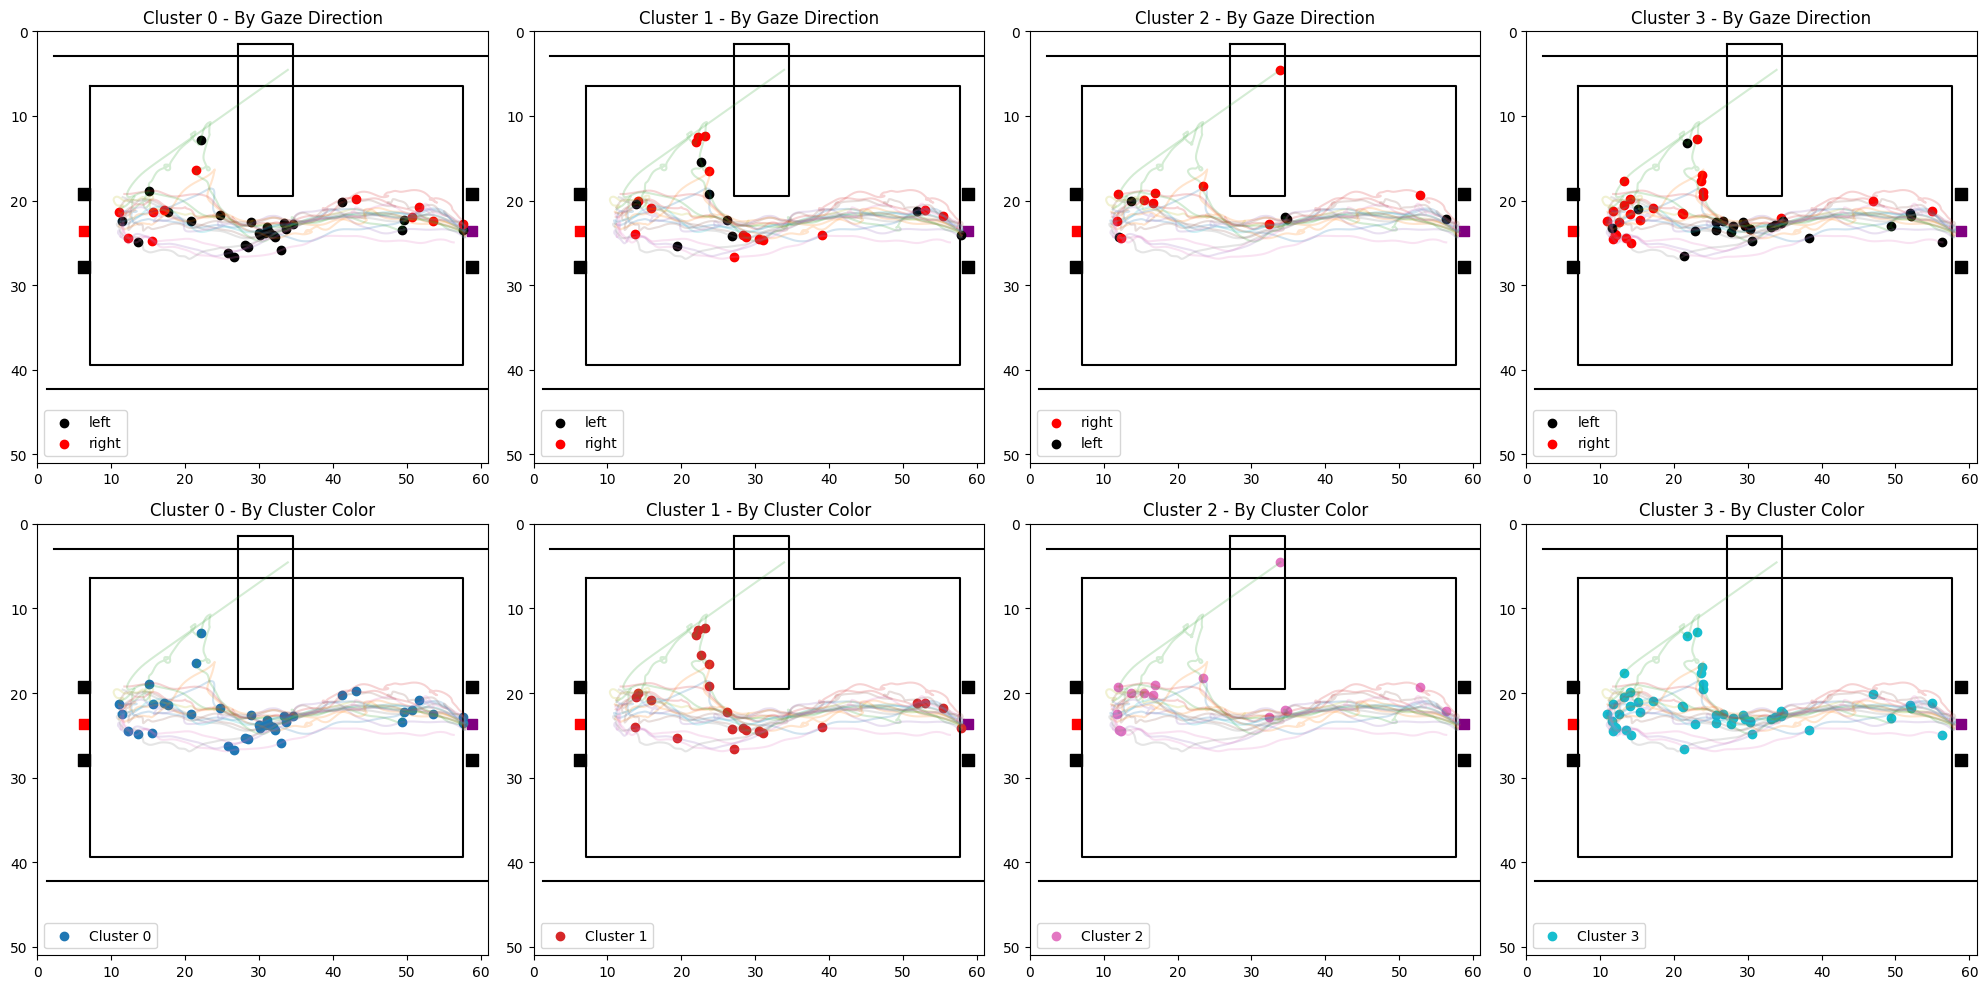

In [59]:
obstacle_cluster_df = F3LITT_050825_df[(F3LITT_050825_df['obstacle_cluster']==0)&(F3LITT_050825_df['odd']=='left')]
imu = F3LITT_050825_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '050825') &(F3LILT_F3LITT_all_meta.animal == 'F3LITT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

In [129]:
import pandas as pd

# List all DataFrames with their corresponding IDs
dfs = [
    (F3LILT_050925_df, "F3LILT_050925"),
    (F3LILT_050725_df, "F3LILT_050725"),
    (F3LILT_050825_df, "F3LILT_050825"),
    (F3LILT_051225_df, "F3LILT_051225"),
    (F3LILT_051325_df, "F3LILT_051325"),
    (F3LITT_050925_df, "F3LITT_050925"),
    (F3LITT_050725_df, "F3LITT_050725"),
    (F3LITT_050825_df, "F3LITT_050825"),
    (F3LITT_051225_df, "F3LITT_051225"),
    (F3LITT_051325_df, "F3LITT_051325"),
]

# Add a 'source' column to each DataFrame and concatenate
combined_df = pd.concat(
    [df.assign(source=source) for df, source in dfs],
    ignore_index=True  # Reset index to avoid duplicate indices
)

combined_df

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,gt_obstacleBL_y_cm,gt_obstacle_cen_x,gt_obstacle_cen_x_cm,gt_obstacle_cen_y,gt_obstacle_cen_y_cm,obstacle_cluster,mean_gt_obstacle_cen_x_cm,mean_gt_obstacle_cen_y_cm,cluster_label,source
0,46582.773388,46593.391219,"[46582.78318, 46582.799795, 46582.816524, 4658...","[619, 620, 621, 622, 623, 624, 625, 626, 627, ...",30.555741,39.853508,"[0.9849825501441956, 0.9834965467453003, 0.983...",847.509583,41.619534,"[0.9962629675865173, 0.9934366345405579, 0.993...",...,29.718528,420.638307,31.127620,278.936536,20.641559,1,30.922344,23.903194,1.0,F3LILT_050925
1,46593.391219,46606.241574,"[46593.405427, 46593.422182, 46593.43872, 4659...","[[1256, 1257, 1258, 1259, 1260, 1261, 1262, 12...",30.555741,39.853508,"[0.9802578091621399, 0.98014897108078, 0.97173...",847.509583,41.619534,"[0.9968204498291016, 0.9956954717636108, 0.993...",...,29.794414,421.226508,31.171147,279.409725,20.676575,1,30.922344,23.903194,1.0,F3LILT_050925
2,46606.241574,46627.276403,"[46606.245516, 46606.262156, 46606.278835, 466...","[2026, 2027, 2028, 2029, 2030, 2031, 2032, 203...",30.555741,39.853508,"[0.9812756776809692, 0.9880237579345703, 0.984...",847.509583,41.619534,"[0.992985188961029, 0.9954388737678528, 0.9924...",...,29.721393,420.506405,31.117859,278.901513,20.638967,1,30.922344,23.903194,1.0,F3LILT_050925
3,46627.276403,46645.984563,"[46627.289958, 46627.306585, 46627.323238, 466...","[[3288, 3289, 3290, 3291, 3292, 3293, 3294, 32...",30.555741,39.853508,"[0.9582122564315796, 0.9644008278846741, 0.965...",847.509583,41.619534,"[0.9905883073806763, 0.9928293824195862, 0.992...",...,19.384054,436.986773,32.337421,139.484502,10.321981,0,31.434813,10.369255,0.0,F3LILT_050925
4,46645.984563,46655.045644,"[46645.999795, 46646.016524, 46646.033139, 466...","[4410, 4411, 4412, 4413, 4414, 4415, 4416, 441...",30.555741,39.853508,"[0.9779036641120911, 0.9735280871391296, 0.978...",847.509583,41.619534,"[0.9896678924560547, 0.9921684861183167, 0.990...",...,19.356440,436.792841,32.323070,139.339884,10.311279,0,31.434813,10.369255,0.0,F3LILT_050925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,58114.889561,58125.495116,"[58114.898713, 58114.914905, 58114.931558, 581...","[57590, 57591, 57592, 57593, 57594, 57595, 575...",30.500332,39.820435,"[0.9828789234161377, 0.9860536456108093, 0.987...",847.892883,41.564779,"[0.9977208971977234, 0.9978249073028564, 0.997...",...,41.607140,425.634281,31.485704,433.870211,32.094946,2,30.971715,31.948972,2.0,F3LITT_051325
874,58125.495116,58132.610483,"[58125.503884, 58125.520499, 58125.537216, 581...","[[58226, 58227, 58228, 58229, 58230, 58231, 58...",30.500332,39.820435,"[0.9805459380149841, 0.9780095815658569, 0.978...",847.892883,41.564779,"[0.9946411848068237, 0.9936203360557556, 0.992...",...,41.558317,425.610867,31.483972,434.554119,32.145537,2,30.971715,31.948972,2.0,F3LITT_051325
875,58132.610483,58165.963174,"[58132.624294, 58132.640985, 58132.657625, 581...","[58653, 58654, 58655, 58656, 58657, 58658, 586...",30.500332,39.820435,"[0.9837036728858948, 0.9879652261734009, 0.989...",847.892883,41.564779,"[0.9925682544708252, 0.992749035358429, 0.9934...",...,41.578886,425.661475,31.487716,433.881632,32.095790,2,30.971715,31.948972,2.0,F3LITT_051325
876,58165.963174,58174.577856,"[58165.975168, 58165.991808, 58166.008537, 581...","[[60653, 60654, 60655, 60656, 60657, 60658, 60...",30.500332,39.820435,"[0.9746934771537781, 0.9722489714622498, 0.979...",847.892883,41.564779,"[0.9951392412185669, 0.9956421852111816, 0.995...",...,41.582209,425.960129,31.509808,435.609098,32.223577,2,30.971715,31.948972,2.0,F3LITT_051325


In [180]:
obstacle_cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==2) & (F3LILT_051325_df['odd']=='left')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325')]
gaze_timestmps = gaze_df['gaze_timestamp'].to_numpy()

# Get unique clusters from gaze data
unique_clusters = sorted(gaze_df['cluster'].dropna().unique())
num_clusters = len(unique_clusters)

# Create figure with subplots - two rows (gaze direction and cluster color)
fig, axes = plt.subplots(2, num_clusters, figsize=(5*num_clusters, 10))
if num_clusters == 1:
    axes = np.array([[axes[0]], [axes[1]]])  # Ensure proper 2D array structure

# Create colormaps
direction_colors = {'right': 'red', 'left': 'black'}
cluster_colors = plt.cm.get_cmap('tab10', len(unique_clusters))  # Using a colormap for clusters

# Plot each cluster in its own column
for col, cluster in enumerate(unique_clusters):
    # Top row - colored by gaze direction
    ax_dir = axes[0, col]
    plot_arena(obstacle_cluster_df, axis=ax_dir)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_dir, cluster=0)
    ax_dir.set_title(f'Cluster {int(cluster)} - By Gaze Direction')
    
    # Bottom row - colored by cluster
    ax_clust = axes[1, col]
    plot_arena(obstacle_cluster_df, axis=ax_clust)
    plot_orginal_obstacle(obstacle_cluster_df, axis=ax_clust, cluster=0)
    ax_clust.set_title(f'Cluster {int(cluster)} - By Cluster Color')
    
    # Iterate through each trial
    for ind, row in obstacle_cluster_df.iterrows():
        # Plot head trajectory in both subplots
        ax_dir.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        ax_clust.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
        
        # Find matching gaze frames for this trial
        trial_gaze_idx, trial_indx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            gaze_timestmps
        )
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        
        # Filter gazes for this specific cluster
        cluster_gazes = trial_gazes[trial_gazes['cluster'] == cluster]
        
        # Plot each gaze in this cluster
        for _, gaze_row in cluster_gazes.iterrows():
            _, trial_pt_idx = find_event_frames(
                row.ts_trial_timestamps - correct_timestamp,
                np.array([gaze_row.gaze_timestamp])
            )
            
            if len(trial_pt_idx) > 0:
                # Top plot - colored by gaze direction
                color_dir = direction_colors.get(gaze_row['gaze_direction'], 'gray')
                ax_dir.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_dir,
                    label=gaze_row['gaze_direction']
                )
                
                # Bottom plot - colored by cluster
                color_clust = cluster_colors(col)  # Same color for all points in this column
                ax_clust.scatter(
                    row.ts_head_cen_x_cm[trial_pt_idx[0]],
                    row.ts_head_cen_y_cm[trial_pt_idx[0]],
                    color=color_clust,
                    label=f'Cluster {int(cluster)}'
                )
    
    # Add legends
    for ax in [ax_dir, ax_clust]:
        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

KeyError: 'cluster'

In [52]:
gaze_timestmps

array([   6.083245 ,    6.183021 ,    6.217005 , ..., 1056.527847 ,
       1064.120979 , 1064.7890755])

In [51]:
row.ts_trial_timestamps - correct_timestamp

array([830.2228350000005, 830.2390020000021, 830.2561669999996,
       830.2723709999991, 830.2890370000023, 830.3057030000055,
       830.322368000001, 830.3390340000042, 830.3557380000057,
       830.3724550000043, 830.3890820000015, 830.4057470000043,
       830.4224770000001, 830.4397190000018, 830.4557700000005,
       830.4725509999989, 830.4891390000048, 830.5058310000022,
       830.522957000001, 830.5391490000038, 830.5558660000024,
       830.5726209999993, 830.589184000004, 830.6063490000015,
       830.6229250000033, 830.6392190000042, 830.6564870000002,
       830.6727040000042, 830.689280000006, 830.7059330000047,
       830.7225990000006, 830.739763000005, 830.7562500000058,
       830.7727230000019, 830.7893120000008, 830.805978000004,
       830.8226820000054, 830.8397570000016, 830.8559870000026,
       830.8727170000057, 830.8893830000015, 830.9060480000044,
       830.922688000006, 830.9394180000018, 830.9560960000017,
       830.9728000000032, 830.9894150000036, 83

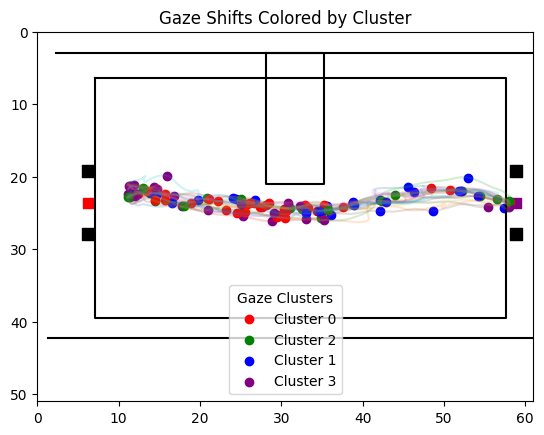

In [49]:
obstacle_cluster_df = F3LITT_051325_df[(F3LITT_051325_df['obstacle_cluster']==0)&(F3LITT_051325_df['odd']=='left')]
imu = F3LITT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_F3LITT_all_meta[(F3LILT_F3LITT_all_meta.date == '051325') &(F3LILT_F3LITT_all_meta.animal == 'F3LITT')]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
# Create a colormap for different clusters
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange'}  # Add more if needed

fig, ax = plt.subplots()
plot_arena(obstacle_cluster_df, axis=ax)
plot_orginal_obstacle(obstacle_cluster_df, axis=ax, cluster=0)

# Iterate through each trial in the obstacle cluster dataframe
for ind, row in obstacle_cluster_df.iterrows():
    # Correct the timestamps
    correct_trial_ts = row.ts_trial_timestamps - correct_timestamp
    
    # Find matching gaze frames for this trial
    trial_gaze_idx, trial_indx = find_event_frames(row.ts_trial_timestamps - correct_timestamp, gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    
    # Plot the head trajectory for this trial
    ax.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm, alpha=0.2)
    
    # Iterate through each gaze in this trial
    for gaze_idx, gaze_row in trial_gazes.iterrows():
        cluster = gaze_row['cluster']
        if pd.isna(cluster):  # Skip if cluster is NaN
            continue
            
        cluster = int(cluster)  # Ensure cluster is integer for color mapping
        color = cluster_colors.get(cluster, 'gray')  # Default to gray if cluster not in colormap
        
        # Find the matching timestamp index in the trial data
        _, trial_pt_idx = find_event_frames(
            row.ts_trial_timestamps - correct_timestamp, 
            np.array([gaze_row.gaze_timestamp])
        )
        
        if len(trial_pt_idx) > 0:
            # Plot the gaze point
            ax.scatter(
                row.ts_head_cen_x_cm[trial_pt_idx[0]],
                row.ts_head_cen_y_cm[trial_pt_idx[0]],
                color=color,
                label=f'Cluster {cluster}'
            )

# Add legend and title
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicates
ax.legend(unique_labels.values(), unique_labels.keys(), title='Gaze Clusters')
ax.set_title('Gaze Shifts Colored by Cluster')

plt.show()

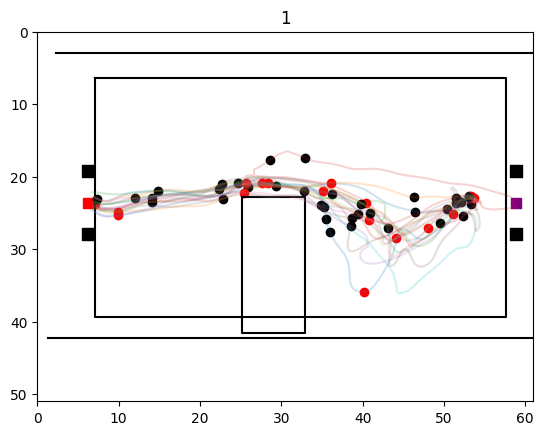

In [1312]:
cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==2)&(F3LILT_051325_df['odd']=='right')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325') ]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 1
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if np.abs(cluster_row[1].dGaze_value) >450:
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

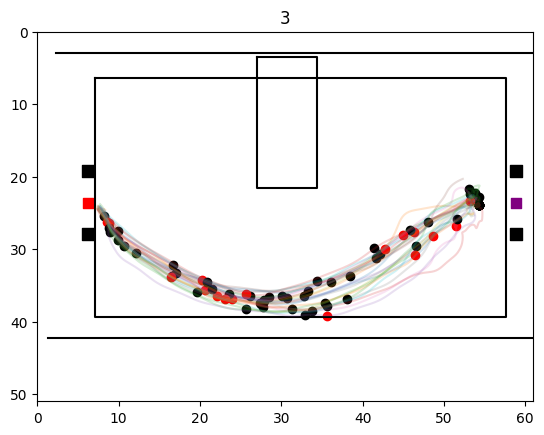

In [1213]:
cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==0)&(F3LILT_051325_df['odd']=='right')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325') ]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 3
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if np.abs(cluster_row[1].dGaze_value) >300:
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

In [1191]:
cluster_row[1]

animal                   F3LILT
date                     051325
gaze_onset_index          61858
gaze_timestamp      1031.468365
window_left                   5
window_right                 15
window_size                  21
has_nan                   False
is_zero                   False
gaze_direction            right
dGaze_value         -218.269191
cluster                       0
cluster_variance       0.166589
Name: 2258, dtype: object

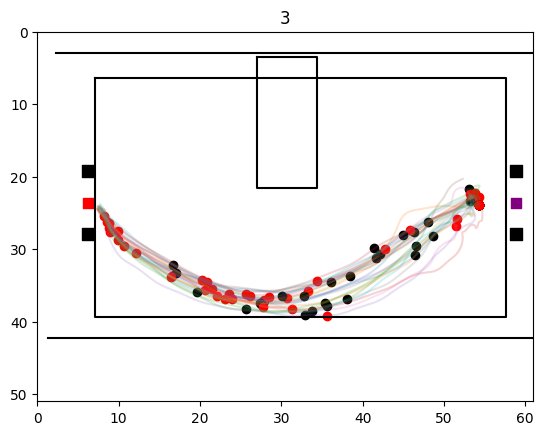

In [1177]:
cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==0)&(F3LILT_051325_df['odd']=='right')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325') ]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 3
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].gaze_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

In [1154]:
for i,row in enumerate(cluster_gaze.iterrows()):
    print(i)

0
1


In [1156]:
row[1]

animal                   F3LILT
date                     051325
gaze_onset_index          61858
gaze_timestamp      1031.468365
window_left                   5
window_right                 15
window_size                  21
has_nan                   False
is_zero                   False
gaze_direction            right
dGaze_value         -218.269191
cluster                       0
cluster_variance       0.166589
Name: 2258, dtype: object

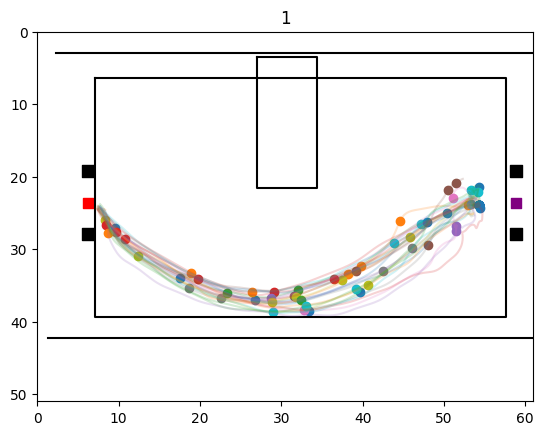

In [1146]:
cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==0)&(F3LILT_051325_df['odd']=='right')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325') ]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(1)
cluster = 1
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster],row.ts_head_cen_y_cm[trial_indx_cluster])

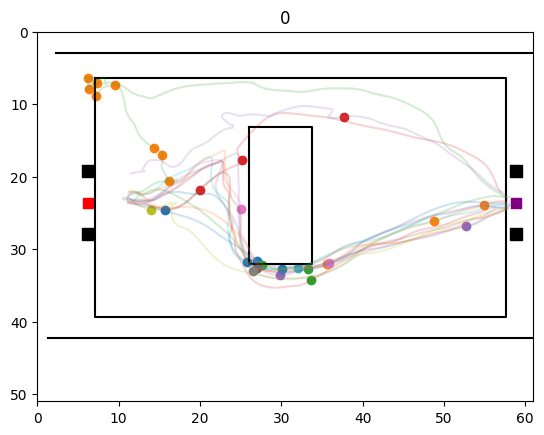

In [1052]:
cluster_df = F3LILT_051325_df[(F3LILT_051325_df['obstacle_cluster']==1)&(F3LILT_051325_df['odd']=='left')]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325') ]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
test = cluster_df.sample(0)
cluster = 0
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster],row.ts_head_cen_y_cm[trial_indx_cluster])



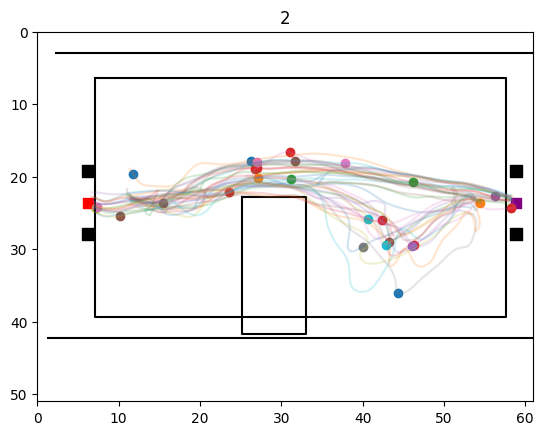

In [1027]:
obstacle_cluster = 2
cluster_df = F3LILT_051325_df[F3LILT_051325_df['obstacle_cluster']==obstacle_cluster]
imu = F3LILT_051325_imu
correct_timestamp = imu['Openephys_time'][0]
gaze_df = F3LILT_all_meta[(F3LILT_all_meta.date == '051325') ]
gaze_timestmps= gaze_df['gaze_timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=obstacle_cluster)
test = cluster_df.sample(1)
cluster = 2
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    correct_trial_ts = row.ts_trial_timestamps-imu['Openephys_time'][0]
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps-correct_timestamp,gaze_timestmps)
    trial_gazes = gaze_df.iloc[trial_gaze_idx]
    cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
    cluster_gaze_ts = cluster_gaze.gaze_timestamp.to_numpy()
    trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps-correct_timestamp,cluster_gaze_ts)
    ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster],row.ts_head_cen_y_cm[trial_indx_cluster])


In [925]:
row.ts_trial_timestamps.shape

(219,)

In [906]:
trial_indx_cluster

[247]

In [ ]:
gaze_df.iloc[trial_gaze_idx]

,animal,date,gaze_onset_index,gaze_timestamp,window_left,window_right,window_size,has_nan,is_zero,cluster,cluster_variance
889,F3LILT,051325,61912,1032.372109,5,15,21,False,False,0,0.166589
890,F3LILT,051325,61936,1032.772224,5,15,21,False,False,11,0.021882
2250,F3LILT,051325,61703,1028.884083,5,15,21,False,False,4,0.053420
2251,F3LILT,051325,61769,1029.983981,5,15,21,False,False,2,0.077283
2252,F3LILT,051325,61773,1030.051866,5,15,21,False,False,3,0.064423
2253,F3LILT,051325,61779,1030.152154,5,15,21,False,False,6,0.042731
2254,F3LILT,051325,61806,1030.600217,5,15,21,False,False,5,0.049045
2255,F3LILT,051325,61813,1030.718112,5,15,21,False,False,8,0.030984
2256,F3LILT,051325,61815,1030.752090,5,15,21,False,False,8,0.030984
2257,F3LILT,051325,61834,1031.067878,5,15,21,False,False,8,0.030984


In [ ]:
find_event_frames(cluster_df.iloc[11].trial_timestamps-imu['Openephys_time'][0],gaze_df.gaze_timestamp.to_numpy())

In [ ]:
F3LILT_TT_df = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_meta_new.h5")

F3LILT_TT_imu_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_imu_data_df.h5")

F3LILT_TT_gaze_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_meta_new.h5")